Total Spins             : 10,000,000
Total Wagered           : 10,000,000.00 Credits
Total Won               : 9,022,176.00 Credits
Simulated RTP           : 90.2218%
Hit Frequency           : 18.63%
Volatility (Std Dev)    : 6.8972
95% Confidence Margin   : ±0.4275%


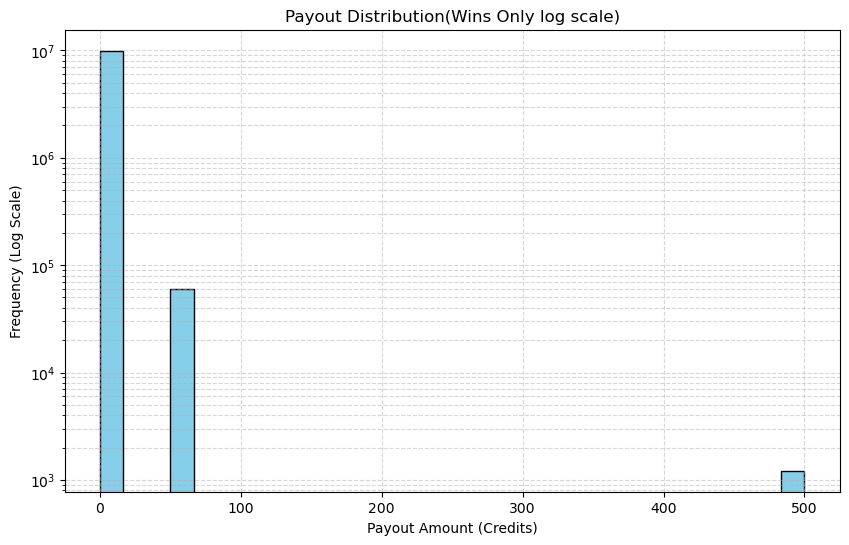

In [12]:
import numpy as np
import matplotlib.pyplot as plt
# 7= Jackpot, B=Bar, C=Cherry, R=Respin, _=Black

reel1=np.array(['7']*1+['B']*4+['C']*6+['_']*9)
reel2=np.array(['7']*1+['B']*4+['C']*6+['_']*9)
reel3=np.array(['7']*1+['B']*3+['C']*5+['R']*2+['_']*9)

N = 10_000_000 # Number of spins
Bet=1  # Bet per spin

idx1=np.random.randint(0, 20, size=N)  # 10m numbers, 20 stops each
idx2=np.random.randint(0, 20, size=N)    
idx3=np.random.randint(0, 20, size=N)

r1=reel1[idx1]
r2=reel2[idx2]
r3=reel3[idx3]

payout = np.zeros(N)

jackpot = (r1=='7') & (r2=='7') & (r3=='7')
payout[jackpot] = 500

bar = (r1=='B') & (r2=='B') & (r3=='B')
payout[bar] = 50

cherry = (r1=='C') & (r2=='C') & (r3=='C')
payout[cherry] = 10

cherry_only_on_reel1 = (r1=='C') & (r2!='C') & (r3!='C')
payout[cherry_only_on_reel1] = 2

respin_mask = (r3 == 'R')
respin_count = np.sum(respin_mask)
if respin_count > 0:
    respin_idx1 = np.random.randint(0, 20, size=respin_count)
    respin_idx2 = np.random.randint(0, 20, size=respin_count)
    respin_r1 = reel1[respin_idx1]
    respin_r2 = reel2[respin_idx2]
    respin_r3 = r3[respin_mask]  # This will always be 'R'

    respin_wins = np.zeros(respin_count)

    # Check for payouts on the respin
    jackpot_respin = (respin_r1 == '7') & (respin_r2 == '7') & (respin_r3 == '7')
    payout[respin_mask][jackpot_respin] = 500

    bar_respin = (respin_r1 == 'B') & (respin_r2 == 'B') & (respin_r3 == 'B')
    payout[respin_mask][bar_respin] = 50

    cherry_respin = (respin_r1 == 'C') & (respin_r2 == 'C') & (respin_r3 == 'C')
    payout[respin_mask][cherry_respin] = 10

    cherry_only_on_reel1_respin = (respin_r1 == 'C') & (respin_r2 != 'C') & (respin_r3 != 'C')
    payout[respin_mask][cherry_only_on_reel1_respin] = 2

    payout[respin_mask] += respin_wins * 3.0

total_wagered = N * Bet
total_won=np.sum(payout)
rtp = total_won / total_wagered*100
hit_frequency = np.count_nonzero(payout > 0) / N * 100
volatility = np.std(payout)
margin_of_error = 1.96 * (volatility / np.sqrt(N))*100

print(f"Total Spins             : {N:,}")
print(f"Total Wagered           : {total_wagered:,.2f} Credits")
print(f"Total Won               : {total_won:,.2f} Credits")
print(f"Simulated RTP           : {rtp:.4f}%")
print(f"Hit Frequency           : {hit_frequency:.2f}%")
print(f"Volatility (Std Dev)    : {volatility:.4f}")
print(f"95% Confidence Margin   : ±{margin_of_error:.4f}%")

plt.figure(figsize=(10, 6))
plt.hist(payout, bins=30,color='skyblue', edgecolor='black', log=True)
plt.title('Payout Distribution(Wins Only log scale)')
plt.xlabel('Payout Amount (Credits)')
plt.ylabel('Frequency (Log Scale)')
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.show()